In [1]:
# Mobility Heatmap Analysis Notebook
import pandas as pd
import numpy as np
import geopandas as gpd
import pickle as pkl
from shapely.geometry import Point, box
from geolib import geohash as geolib

# -------------------------------------------------------
# Load Data
# -------------------------------------------------------

paths = pd.read_csv("data/all_paths_128_cleaned.csv", sep=";")
movements = pd.read_csv("data/all_movements_117.csv", sep=";")

# -------------------------------------------------------
# Load / init cache
# -------------------------------------------------------
try:
    geohashes_cache = pkl.load(open("./geohashes_to_coords.pkl", "rb"))
except FileNotFoundError:
    geohashes_cache = {}

# Read geohashes to coordinates mapping (dataframe with columns: geohash, latitude, longitude)
geo_to_coords = pd.read_pickle('geohashes_to_coords.pkl')

# Function to complete geo_to_coords with missing geohashes
def complete_geo_to_coords(geo_to_coords, geohashes):
    missing_geohashes = set(geohashes) - set(geo_to_coords['geohash'])
    new_rows = []
    for gh in missing_geohashes:
        lat, lon = geolib.decode(gh)
        new_rows.append({'geohash': gh, 'latitude': lat, 'longitude': lon})
    if new_rows:
        geo_to_coords = pd.concat([geo_to_coords, pd.DataFrame(new_rows)], ignore_index=True)
        geo_to_coords.to_pickle('geohashes_to_coords.pkl') # Save to file
    return geo_to_coords

In [2]:
# Transform date strings to datetime objects, keeping only date part
paths["date"] = pd.to_datetime(paths["date"], errors='coerce').dt.date

In [3]:
# Heatwave dates (13, 14, 22, 25, 29, 30 June 2025, 1,2 July 2025, 9, 12, 13, 14, 15 August 2025) -> T >= 30C
heatwave_days = [
    "2025-06-13", "2025-06-14", "2025-06-22", "2025-06-25", "2025-06-29", "2025-06-30",
    "2025-07-01", "2025-07-02",
    "2025-08-09", "2025-08-12", "2025-08-13", "2025-08-14", "2025-08-15"
]
heatwave_days = pd.to_datetime(heatwave_days)

In [4]:
# Geohashes in switzerland
swiss_geohashes = [f"u0{c}" for c in "kmqrhjnp"]
# Keep only bern
#swiss_geohashes = ["u0m"]
# Keep only zurich-winterthur
#swiss_geohashes = ["u0q"]

# Translate selected modes of transport to corresponding actual transport modes
def translate_mot(mot):
    if mot == "CAR" or mot == "ELECTRIC_CAR" or mot == "HYBRID_CAR":
        return "Car"
    elif mot == "TRAIN":
        return "Train"
    elif mot == "WALKING":
        return "Walking"
    elif mot == "ON_BICYCLE" or mot == "ELECTRIC_BIKE" or mot == "SCOOTER" or mot == "ELECTRIC_SCOOTER":
        return "Bicycle"
    elif mot == "BUS" or mot == "ELECTRIC_BUS" or mot == "COACH":
        return "Bus"
    elif mot == "TRAM":
        return "Tram"
    elif mot == "PLANE":
        return "Plane"
    elif mot == "BOAT" or mot == "BOAT_NO_ENGINE":
        return "Boat"
    else:
        return mot

In [5]:
# Keep only max 7 characters of geohash for paths
paths['geohash'] = paths['geohash'].str.slice(0, 8)

In [6]:
# Keep only data in switzerland
paths = paths[(paths['geohash'].str.startswith(tuple(swiss_geohashes)))]

# Translate mean of transport by simplifying (e.g., CAR, ELECTRIC_CAR, HYBRID_CAR -> CAR)
paths['mean_of_transport'] = paths['mode_of_transport'].apply(translate_mot)

In [7]:
all_geohashes = set(paths['geohash'].dropna().unique())
geo_to_coords = complete_geo_to_coords(geo_to_coords, all_geohashes)

In [8]:
# -------------------------------------------------------
# Merge coordinates back into paths
# -------------------------------------------------------
paths = paths.merge(geo_to_coords, on='geohash', how="left")

In [9]:
paths

,time_range,day_of_week,month,mode_of_transport,geohash,direction,dow_num,date,bad_date,mean_of_transport,latitude,longitude
0,18-21,TUESDAY,8,BUS,u0m70dcm,EAST,1,2024-08-13,False,Bus,46.949644,7.406673
1,18-21,TUESDAY,8,BUS,u0m70ddq,NORTH_WEST,1,2024-08-13,False,Bus,46.948442,7.408047
2,18-21,TUESDAY,8,BUS,u0m70dfh,EAST,1,2024-08-13,False,Bus,46.949472,7.407703
3,6-9,WEDNESDAY,8,ON_BICYCLE,u0m70fqv,NORTH_EAST,2,2024-08-14,False,Bicycle,46.946898,7.425213
4,6-9,WEDNESDAY,8,ON_BICYCLE,u0m70fqk,EAST,2,2024-08-14,False,Bicycle,46.946726,7.424526
...,...,...,...,...,...,...,...,...,...,...,...,...
1241141,13-14,TUESDAY,12,ON_BICYCLE,u0m70fm3,WEST,1,2025-12-16,False,Bicycle,46.946211,7.423153
1241142,13-14,TUESDAY,12,ON_BICYCLE,u0m70dr8,SOUTH_WEST,1,2025-12-16,False,Bicycle,46.946039,7.415257
1241143,13-14,TUESDAY,12,ON_BICYCLE,u0m70f6c,WEST,1,2025-12-16,False,Bicycle,46.946211,7.41972
1241144,13-14,TUESDAY,12,ON_BICYCLE,u0m70fk3,WEST,1,2025-12-16,False,Bicycle,46.946211,7.42178


In [10]:
# Add is_heatwave_day column
paths['date'] = pd.to_datetime(paths['date'], errors='coerce')
paths['is_heatwave_day'] = paths['date'].isin(heatwave_days)

In [11]:
paths

,time_range,day_of_week,month,mode_of_transport,geohash,direction,dow_num,date,bad_date,mean_of_transport,latitude,longitude,is_heatwave_day
0,18-21,TUESDAY,8,BUS,u0m70dcm,EAST,1,2024-08-13,False,Bus,46.949644,7.406673,False
1,18-21,TUESDAY,8,BUS,u0m70ddq,NORTH_WEST,1,2024-08-13,False,Bus,46.948442,7.408047,False
2,18-21,TUESDAY,8,BUS,u0m70dfh,EAST,1,2024-08-13,False,Bus,46.949472,7.407703,False
3,6-9,WEDNESDAY,8,ON_BICYCLE,u0m70fqv,NORTH_EAST,2,2024-08-14,False,Bicycle,46.946898,7.425213,False
4,6-9,WEDNESDAY,8,ON_BICYCLE,u0m70fqk,EAST,2,2024-08-14,False,Bicycle,46.946726,7.424526,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1241141,13-14,TUESDAY,12,ON_BICYCLE,u0m70fm3,WEST,1,2025-12-16,False,Bicycle,46.946211,7.423153,False
1241142,13-14,TUESDAY,12,ON_BICYCLE,u0m70dr8,SOUTH_WEST,1,2025-12-16,False,Bicycle,46.946039,7.415257,False
1241143,13-14,TUESDAY,12,ON_BICYCLE,u0m70f6c,WEST,1,2025-12-16,False,Bicycle,46.946211,7.41972,False
1241144,13-14,TUESDAY,12,ON_BICYCLE,u0m70fk3,WEST,1,2025-12-16,False,Bicycle,46.946211,7.42178,False


In [12]:

# -------------------------------------------------------
# Convert geohashes to points (paths)
# -------------------------------------------------------
gdf_paths = gpd.GeoDataFrame(paths, geometry=gpd.points_from_xy(paths["longitude"], paths["latitude"]), crs="EPSG:4326")
gdf_paths = gdf_paths.to_crs(3857)

In [13]:

# -------------------------------------------------------
# Build spatial grid for the city bounding box
# -------------------------------------------------------

minx, miny, maxx, maxy = gdf_paths.total_bounds
grid_size = 100  # meters

xs = np.arange(minx, maxx, grid_size)
ys = np.arange(miny, maxy, grid_size)

grid_cells = []
for x in xs:
    for y in ys:
        grid_cells.append(box(x, y, x+grid_size, y+grid_size))

grid = gpd.GeoDataFrame({"geometry": grid_cells})
grid = grid.set_crs(3857)
grid["cell_id"] = grid.index

In [14]:
# -------------------------------------------------------
# Spatial join: assign path points to cells
# -------------------------------------------------------

joined = gpd.sjoin(gdf_paths, grid, how="left", predicate="within")

cell_month = (
    joined.groupby(["cell_id", "date", "mean_of_transport", "is_heatwave_day"])
    .size()
    .reset_index(name="count")
)

In [15]:

# -------------------------------------------------------
# Movement: monthly active users
# -------------------------------------------------------

movements["start_time"] = pd.to_datetime(movements["start_time"])
movements["date"] = movements["start_time"].dt.date
active_users = movements.groupby("date")["participant_id"].nunique().reset_index(name="n_users")

In [16]:
# Convert date column to datetime.date in both cell_month and active_users
cell_month['date'] = pd.to_datetime(cell_month['date']).dt.date
active_users['date'] = pd.to_datetime(active_users['date']).dt.date

In [17]:
# -------------------------------------------------------
# Normalize per user
# -------------------------------------------------------

df = cell_month.merge(active_users, left_on="date", right_on="date", how="left")
df["norm_intensity"] = df["count"] / df["n_users"]

In [18]:
df

,cell_id,date,mean_of_transport,is_heatwave_day,count,n_users,norm_intensity
0,1812.0,2025-05-01,Train,False,1,16.0,0.062500
1,3475.0,2025-06-07,Car,False,1,30.0,0.033333
2,3475.0,2025-07-27,Car,False,1,17.0,0.058824
3,5843.0,2025-07-20,Train,False,1,19.0,0.052632
4,6354.0,2025-05-01,Train,False,1,16.0,0.062500
...,...,...,...,...,...,...,...
973251,28422926.0,2025-09-14,Car,False,1,12.0,0.083333
973252,28430930.0,2025-09-30,Car,False,1,16.0,0.062500
973253,28431049.0,2025-10-02,Train,False,1,18.0,0.055556
973254,28435457.0,2025-09-30,Car,False,1,16.0,0.062500


In [19]:
df.groupby("cell_id")["is_heatwave_day"].value_counts()

cell_id     is_heatwave_day
1812.0      False              1
3475.0      False              2
5843.0      False              1
6354.0      False              1
6355.0      False              1
                              ..
28422926.0  False              1
28430930.0  False              1
28431049.0  False              1
28435457.0  False              1
28435592.0  False              1
Name: count, Length: 239814, dtype: int64

In [20]:
# Consider only modes of transport walking, cycling and boat
modes_of_interest = ["Walking", "Bicycle", "Boat"]
df = df[df["mean_of_transport"].isin(modes_of_interest)]

In [21]:
# -------------------------------------------------------
# Permutation test per cell
# -------------------------------------------------------

from scipy.stats import permutation_test
from statsmodels.stats.multitest import multipletests

results = []

for cell in df["cell_id"].unique():
    subset = df[df["cell_id"] == cell]

    warm_vals = subset[subset["is_heatwave_day"] == 1]["norm_intensity"].dropna()
    cold_vals = subset[subset["is_heatwave_day"] == 0]["norm_intensity"].dropna()

    if len(warm_vals) < 2 or len(cold_vals) < 2:
        results.append([cell, np.nan])
        continue
    
    res = permutation_test(
        (warm_vals, cold_vals),
        statistic=lambda x, y: x.mean() - y.mean(),
        alternative="two-sided",
        n_resamples=5000, #5000,
    )
    results.append([cell, res.pvalue])

results_df = pd.DataFrame(results, columns=["cell_id", "p"])

In [22]:

# -------------------------------------------------------
# Multiple testing correction
# -------------------------------------------------------

mask = results_df["p"].notna()
reject, p_adj, _, _ = multipletests(results_df.loc[mask, "p"], method="fdr_bh")

results_df.loc[mask, "p_adj"] = p_adj
results_df.loc[mask, "significant"] = reject

results_df.head()


,cell_id,p,p_adj,significant
0,479539.0,NaN,NaN,NaN
1,479540.0,NaN,NaN,NaN
2,479541.0,NaN,NaN,NaN
3,484080.0,NaN,NaN,NaN
4,484081.0,NaN,NaN,NaN


In [23]:
grid_with_stats = grid.merge(results_df, on="cell_id", how="left")

<Axes: >

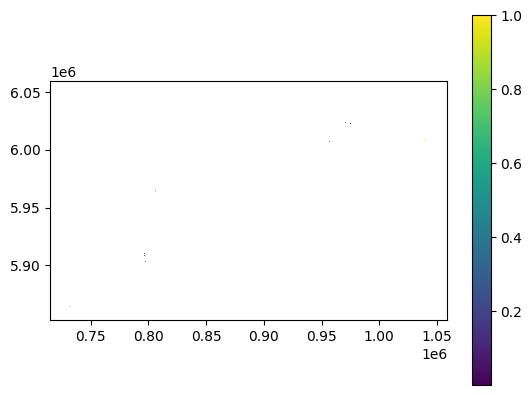

In [24]:
grid_with_stats.plot(column="p", cmap="viridis", legend=True)

In [25]:
grid_with_stats['significant'] = grid_with_stats['p'] < 0.05

In [26]:
import folium
from folium.features import GeoJson

# Calculate warm_cold_diff: difference between warm and cold months
warm_mean = df[df["is_heatwave_day"] == 1].groupby("cell_id")["norm_intensity"].mean()
cold_mean = df[df["is_heatwave_day"] == 0].groupby("cell_id")["norm_intensity"].mean()
diff_df = pd.DataFrame({
    "cell_id": warm_mean.index,
    "warm_cold_diff": warm_mean.values - cold_mean.reindex(warm_mean.index, fill_value=0).values
})

# Merge the difference back into grid_with_stats
grid_with_stats = grid_with_stats.merge(diff_df, on="cell_id", how="left")

# Convert CRS to lat/lon for folium
g = grid_with_stats.to_crs(4326)


In [27]:
m = folium.Map(location=[g.geometry.centroid.y.mean(),
                         g.geometry.centroid.x.mean()],
               zoom_start=12,
               tiles="CartoDB positron")

# Red = warm > cold
warm = g[(g["significant"] == True) & (g["warm_cold_diff"] > 0)]
GeoJson(
    warm.to_json(),
    style_function=lambda x: {"color": "red", "weight": 0, "fillOpacity": 0.6},
).add_to(m)

# Blue = cold > warm
#cold = g[(g["significant"] == True) & (g["warm_cold_diff"] < 0)] # Show only significant differences

cold = g[(g["warm_cold_diff"] < 0)] # Show all differences

GeoJson(
    cold.to_json(),
    style_function=lambda x: {"color": "blue", "weight": 0, "fillOpacity": 0.6},
).add_to(m)

# Grey = non-significant
'''
ns = g[g["significant"] != True]
GeoJson(
    ns.to_json(),
    style_function=lambda x: {"color": "lightgrey", "weight": 0, "fillOpacity": 0.3},
).add_to(m)
'''

/var/folders/hc/bxt7k06n5532f1ws84vbg7180000gn/T/ipykernel_44220/2332414297.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  m = folium.Map(location=[g.geometry.centroid.y.mean(),
/var/folders/hc/bxt7k06n5532f1ws84vbg7180000gn/T/ipykernel_44220/2332414297.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  g.geometry.centroid.x.mean()],


'\nns = g[g["significant"] != True]\nGeoJson(\n    ns.to_json(),\n    style_function=lambda x: {"color": "lightgrey", "weight": 0, "fillOpacity": 0.3},\n).add_to(m)\n'

In [28]:
m.save("maps/heatmap_warm_cold_difference.html")

! open maps/heatmap_warm_cold_difference.html